In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


%matplotlib inline

In [3]:
url = "https://raw.githubusercontent.com/cgveradi/house_martell_project/main/data/clean/df_clean.csv"
df = pd.read_csv(url)

In [4]:
df

,client_id,visitor_id,visit_id,process_step,date_time,Variation,tenure_yrs,clnt_tenure_mnth,age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,3.0,46.0,29.5,Unknown,2.0,25454.66,2.0,6.0
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,3.0,46.0,29.5,Unknown,2.0,25454.66,2.0,6.0
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,3.0,46.0,29.5,Unknown,2.0,25454.66,2.0,6.0
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,3.0,46.0,29.5,Unknown,2.0,25454.66,2.0,6.0
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,3.0,46.0,29.5,Unknown,2.0,25454.66,2.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317230,9999729,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,Test,10.0,124.0,31.0,Female,3.0,107059.74,6.0,9.0
317231,9999729,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,Test,10.0,124.0,31.0,Female,3.0,107059.74,6.0,9.0
317232,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,Test,10.0,124.0,31.0,Female,3.0,107059.74,6.0,9.0
317233,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,Test,23.0,281.0,49.0,Female,2.0,431887.61,1.0,4.0


In [5]:
# Summary statistics for the primary demographic columns

demo_summary = df[['age', 'tenure_yrs', 'bal']].describe()
print("High-Level Client Profile:")
print(demo_summary)

# Check the gender distribution (using the mapping we did earlier)

print("\n----------")
print("\nGender Distribution:")
print(df['gender'].value_counts())

High-Level Client Profile:
                 age     tenure_yrs           bal
count  317123.000000  317135.000000  3.171350e+05
mean       48.528303      12.175562  1.607980e+05
std        15.636554       6.958357  3.408625e+05
min        17.000000       2.000000  2.378944e+04
25%        34.500000       6.000000  4.103359e+04
50%        50.000000      11.000000  6.909005e+04
75%        61.000000      16.000000  1.511617e+05
max        96.000000      55.000000  1.632004e+07

----------

Gender Distribution:
gender
Unknown    107614
Male       106703
Female     102810
Other           8
Name: count, dtype: int64


In [6]:
# Age Bins
df['age_group'] = pd.cut(df['age'], 
                              bins=[0, 35, 60, 100], 
                              labels=['Young (<35)', 'Middle (35-60)', 'Senior (>60)'])

# Tenure Bins
df['tenure_group'] = pd.cut(df['tenure_yrs'], 
                                 bins=[0, 5, 15, 100], 
                                 labels=['New (<5yr)', 'Established (5-15yr)', 'Long-standing (>15yr)'])

# Compare digital behavior across age groups

print("\n----------")
age_behavior = df.groupby('age_group', observed=False)[['logons_6_mnth', 'calls_6_mnth']].mean()
print("\nBehavior by Age Group:")
print(age_behavior)


----------

Behavior by Age Group:
                logons_6_mnth  calls_6_mnth
age_group                                  
Young (<35)          6.215177      3.195345
Middle (35-60)       6.090321      3.057473
Senior (>60)         6.641408      3.575610


In [7]:
# 1. Identify which unique clients reached the 'confirm' step
confirmed_clients = df[df['process_step'] == 'confirm']['client_id'].unique()

# 2. Create a flag at the client level
df_unique = df.drop_duplicates(subset='client_id').copy()
df_unique['is_successful'] = df_unique['client_id'].isin(confirmed_clients)

# 3. Calculate Completion Rate by Age Group
completion_stats = df_unique.groupby('age_group', observed=False)['is_successful'].mean() * 100
print("\nCompletion Rate per Age Segment (%):")
print(completion_stats)


Completion Rate per Age Segment (%):
age_group
Young (<35)       69.158291
Middle (35-60)    68.168629
Senior (>60)      64.445368
Name: is_successful, dtype: float64



Correlation Matrix (Behavioral Insights):
               logons_6_mnth  calls_6_mnth       bal       age
logons_6_mnth       1.000000      0.994372  0.174472  0.084943
calls_6_mnth        0.994372      1.000000  0.167309  0.076143
bal                 0.174472      0.167309  1.000000  0.201108
age                 0.084943      0.076143  0.201108  1.000000


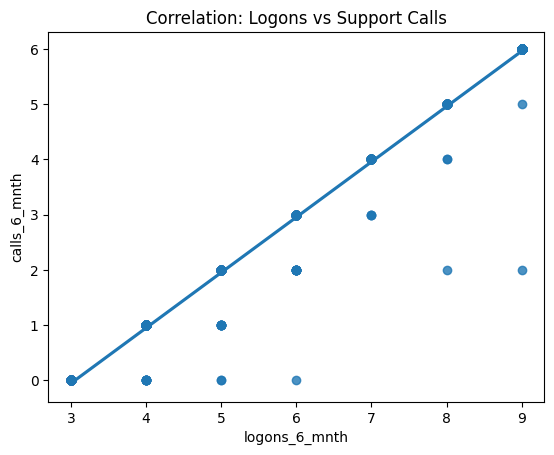

In [8]:
# Calculate correlation between digital activity and support needs
behavior_metrics = df[['logons_6_mnth', 'calls_6_mnth', 'bal', 'age']]
correlation_matrix = behavior_metrics.corr()

print("\nCorrelation Matrix (Behavioral Insights):")
print(correlation_matrix)

# Visualization of the relationship
sns.regplot(data=df_unique.sample(1000), x='logons_6_mnth', y='calls_6_mnth')
plt.title('Correlation: Logons vs Support Calls')
plt.show()

In [9]:
# KPI Metrics

# 1. Completion Rate by Variation

completion_kpi = df_unique.groupby('Variation')['is_successful'].mean() * 100
print("Completion Rate KPI:")
print(completion_kpi)

Completion Rate KPI:
Variation
Control    65.587285
Test       69.293236
Name: is_successful, dtype: float64


In [10]:
# 2. Time Spent on Each Step

# Ensure date_time is datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

# Sort for time calculation
df = df.sort_values(['visit_id', 'date_time'])

# Calculate time difference between rows
df['time_diff'] = df.groupby('visit_id')['date_time'].diff().dt.total_seconds()

# Average time per step by Variation (excluding the very first 'start' step)
time_kpi = df[df['time_diff'].notnull()].groupby(['Variation', 'process_step'])['time_diff'].mean().unstack()
print("Average Time Spent (Seconds) per Step:")
print(time_kpi)


Average Time Spent (Seconds) per Step:
process_step     confirm       start     step_1     step_2     step_3
Variation                                                            
Control       129.976828  177.226089  43.180970  38.838146  94.159651
Test          129.583041  152.885005  37.773991  48.272585  97.356255


In [11]:
# 3. Error Rates

step_map = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}
df['step_num'] = df['process_step'].map(step_map)

# Check for "backward" movement
df['is_error'] = df.groupby('visit_id')['step_num'].diff() < 0

error_kpi = df.groupby('Variation')['is_error'].mean() * 100
print("Error Rate (Backward Movement) %:")
print(error_kpi)


Error Rate (Backward Movement) %:
Variation
Control    6.902146
Test       9.247364
Name: is_error, dtype: float64


In [16]:
# Statistical Test

# 1. Data Setup
successes = df_unique.groupby('Variation')['is_successful'].sum().loc[['Test', 'Control']].values
nobs = df_unique.groupby('Variation')['is_successful'].count().loc[['Test', 'Control']].values

# Proportions
p_test = successes[0] / nobs[0]
p_ctrl = successes[1] / nobs[1]

# 2. Statistical Significance (Z-Test)
p_pooled = (successes[0] + successes[1]) / (nobs[0] + nobs[1])
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/nobs[0] + 1/nobs[1]))
z_stat = (p_test - p_ctrl) / se

# 3. 5% Threshold Check
observed_diff = p_test - p_ctrl
threshold = 0.05
is_cost_effective = observed_diff >= threshold

print(f"--- Statistical Result ---")
print(f"Z-statistic: {z_stat:.4f}")
print(f"Is Significant? (Z > 1.96): {abs(z_stat) > 1.96}")

print(f"\n--- Business Result (5% Threshold) ---")
print(f"Observed Increase: {observed_diff:.2%}")
print(f"Vanguard Threshold: {threshold:.2%}")
print(f"Meets Threshold? {is_cost_effective}")

--- Statistical Result ---
Z-statistic: 8.8745
Is Significant? (Z > 1.96): True

--- Business Result (5% Threshold) ---
Observed Increase: 3.71%
Vanguard Threshold: 5.00%
Meets Threshold? False


In [17]:
# Check average age by Variation
age_check = df_unique.groupby('Variation')['age'].agg(['mean', 'std', 'count'])
print("Age Balance Check:")
print(age_check)

# Check average balance by Variation
bal_check = df_unique.groupby('Variation')['bal'].agg(['mean', 'median'])
print("\nBalance Balance Check:")
print(bal_check)

Age Balance Check:
                mean        std  count
Variation                             
Control    47.498427  15.521781  23526
Test       47.163922  15.514461  26961

Balance Balance Check:
                    mean    median
Variation                         
Control    150147.326660  66024.18
Test       148962.605032  65468.36
